# Student Dropout Risk Prediction — Final Pipeline

**Authors:** Bakhturazov Maxim, Sadykov Arsen (IT-2305)  
**Supervisor:** Alimzhanov E. S.  
**Astana IT University**

---

## Goal
Build a **predictive system** for early identification of students at risk of dropout from learning analytics data.

## Pipeline (this notebook)
1. Load 7 raw OULAD tables → aggregate into **1 final dataset**
2. EDA: shape, class balance
3. Stratified train / test split + **5-fold cross-validation**
4. **Baseline** model: Logistic Regression
5. **Main models**: Random Forest, Gradient Boosting, XGBoost, SVM, KNN
6. **Hyperparameter tuning** with Optuna (XGBoost, Gradient Boosting)
7. Extended metrics: ROC-AUC, Brier Score, Calibration Curve, Confusion Matrix
8. **Probability calibration** (CalibratedClassifierCV, isotonic)
9. **Explainability** with SHAP
10. **Final model selection** + comparison table
11. **Export** model + scaler (joblib) for the dashboard

## 0. Imports

In [1]:

!pip install -q optuna shap xgboost joblib scikit-learn matplotlib seaborn


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, brier_score_loss,
    classification_report, roc_curve
)

# Boosting
from xgboost import XGBClassifier

# Tuning + Explainability
import optuna
import shap

# Save
import joblib

# Pretty
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
RANDOM_STATE = 42

optuna.logging.set_verbosity(optuna.logging.WARNING)
print('All libraries loaded')

All libraries loaded


## 1. Load 7 raw OULAD tables




In [3]:
studentInfo         = pd.read_csv('studentInfo.csv')
studentRegistration = pd.read_csv('studentRegistration.csv')
studentAssessment   = pd.read_csv('studentAssessment.csv')
assessments         = pd.read_csv('assessments.csv')
courses             = pd.read_csv('courses.csv')
vle                 = pd.read_csv('vle.csv')
studentVle          = pd.read_csv('studentVle.csv', engine='python', on_bad_lines='skip')

raw_tables = {
    'studentInfo':         studentInfo,
    'studentRegistration': studentRegistration,
    'studentAssessment':   studentAssessment,
    'assessments':         assessments,
    'courses':             courses,
    'vle':                 vle,
    'studentVle':          studentVle,
}

print('=== RAW OULAD TABLES (7) ===')
for name, t in raw_tables.items():
    print(f'  {name:22s}  shape = {t.shape}')


=== RAW OULAD TABLES (7) ===
  studentInfo             shape = (32593, 12)
  studentRegistration     shape = (32593, 5)
  studentAssessment       shape = (173912, 5)
  assessments             shape = (206, 6)
  courses                 shape = (22, 3)
  vle                     shape = (6364, 6)
  studentVle              shape = (10655280, 6)


## 2. Target variable

Binary classification:  
`1 = Withdrawn (dropout)`, `0 = continued / passed / failed`.

In [4]:
studentInfo['target'] = studentInfo['final_result'].apply(
    lambda x: 1 if x == 'Withdrawn' else 0
)

print('Target distribution in studentInfo:')
print(studentInfo['target'].value_counts())
print(f"\nDropout rate: {studentInfo['target'].mean():.2%}")

Target distribution in studentInfo:
target
0    22437
1    10156
Name: count, dtype: int64

Dropout rate: 31.16%


## 3. Feature Engineering — 7 tables → 1 aggregated dataset

Aggregation key: `(id_student, code_module, code_presentation)` — one row per student per course.

In [7]:
keys = ['id_student', 'code_module', 'code_presentation']

# --- VLE (engagement) ---
vle_features = studentVle.groupby(keys).agg(
    total_clicks=('sum_click', 'sum'),
    avg_clicks=('sum_click', 'mean'),
    activity_count=('sum_click', 'count'),
    active_days=('date', 'nunique')
).reset_index()

# --- Assessments (academic performance) ---
studentAssessment_full = studentAssessment.merge(assessments, on='id_assessment', how='left')

assessment_features = studentAssessment_full.groupby(keys).agg(
    avg_score=('score', 'mean'),
    total_score=('score', 'sum'),
    num_assessments=('score', 'count')
).reset_index()

# --- Registration ---
reg_features = studentRegistration[keys + ['date_registration']].copy()

# --- Final aggregated dataset ---
df = studentInfo.merge(vle_features,        on=keys, how='left')
df = df.merge(assessment_features,          on=keys, how='left')
df = df.merge(reg_features,                 on=keys, how='left')

# Fill missing engagement / score with 0 (= no activity recorded)
df.fillna(0, inplace=True)

print(f'✓ FINAL aggregated dataset: {df.shape[0]} rows × {df.shape[1]} cols')
print(f'  Duplicates by key: {df[keys].duplicated().sum()}')

TypeError: Invalid value '0' for dtype 'str'. Value should be a string or missing value, got 'int' instead.

In [ ]:
print('=== Final dataset preview ===')
df.head()

=== Final dataset preview ===


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,...,final_result,target,total_clicks,avg_clicks,activity_count,active_days,avg_score,total_score,num_assessments,date_registration
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,...,Pass,0,934.0,4.765306,196.0,40.0,82.0,410.0,5.0,-159.0
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,...,Pass,0,1435.0,3.337209,430.0,80.0,66.4,332.0,5.0,-53.0
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,...,Withdrawn,1,281.0,3.697368,76.0,12.0,0.0,0.0,0.0,-92.0
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,...,Pass,0,2158.0,3.254902,663.0,123.0,76.0,380.0,5.0,-52.0
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,...,Pass,0,1034.0,2.937500,352.0,70.0,54.4,272.0,5.0,-176.0


## 4. EDA — class balance

**Замечание научрука:** сколько всего записей, сколько dropout / non-dropout, баланс классов.

Total records: 32593

Non-dropout (0):   22437  (68.84%)
Dropout     (1):   10156  (31.16%)


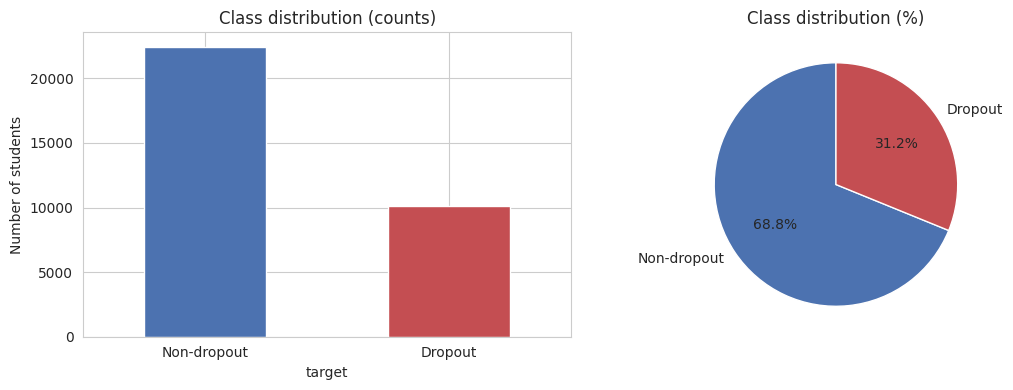

In [ ]:
print(f'Total records: {len(df)}')
print()
vc = df['target'].value_counts()
print(f'Non-dropout (0):  {vc.get(0,0):>6}  ({vc.get(0,0)/len(df):.2%})')
print(f'Dropout     (1):  {vc.get(1,0):>6}  ({vc.get(1,0)/len(df):.2%})')

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
vc.plot(kind='bar', ax=ax[0], color=['#4C72B0', '#C44E52'])
ax[0].set_xticklabels(['Non-dropout', 'Dropout'], rotation=0)
ax[0].set_title('Class distribution (counts)')
ax[0].set_ylabel('Number of students')

ax[1].pie(vc.values, labels=['Non-dropout', 'Dropout'],
          autopct='%1.1f%%', colors=['#4C72B0', '#C44E52'], startangle=90)
ax[1].set_title('Class distribution (%)')
plt.tight_layout(); plt.show()

## 5. Encoding

In [ ]:
categorical_cols = df.select_dtypes(include=['object']).columns
categorical_cols = [c for c in categorical_cols if c != 'final_result']
print('Categorical columns to encode:', categorical_cols)

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

Categorical columns to encode: ['code_module', 'code_presentation', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'disability']


## 6. Train / Test Split — STRATIFIED

**Замечание научрука:** показать train / test размеры и распределение классов в каждом.

In [ ]:
X = df.drop(['target', 'final_result'], axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,        # <-- preserves class balance
    random_state=RANDOM_STATE
)

X_test_orig = X_test.copy()  # unscaled copy for SHAP / display

print(f'Train size: {len(X_train):>6}   ({len(X_train)/len(df):.0%})')
print(f'Test  size: {len(X_test):>6}   ({len(X_test)/len(df):.0%})')
print()
print('Class distribution after stratified split:')
print(f'  Train  →  non-dropout: {(y_train==0).sum():>5}  | dropout: {(y_train==1).sum():>5}  '
      f'(dropout rate {y_train.mean():.2%})')
print(f'  Test   →  non-dropout: {(y_test==0).sum():>5}  | dropout: {(y_test==1).sum():>5}  '
      f'(dropout rate {y_test.mean():.2%})')

Train size:  26074   (80%)
Test  size:   6519   (20%)

Class distribution after stratified split:
  Train  →  non-dropout: 17949  | dropout:  8125  (dropout rate 31.16%)
  Test   →  non-dropout:  4488  | dropout:  2031  (dropout rate 31.16%)


## 7. Scaling

In [ ]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
feature_names = X.columns.tolist()
print(f'Scaled. Number of features: {len(feature_names)}')

Scaled. Number of features: 19


## 8. Helper — full evaluation function

Returns: Accuracy, Precision, Recall, F1, ROC-AUC, Brier.

In [ ]:
def evaluate(model, X_te, y_te, name='Model'):
    """Full evaluation with all required metrics."""
    if hasattr(model, 'predict_proba'):
        probs = model.predict_proba(X_te)[:, 1]
    else:
        d = model.decision_function(X_te)
        probs = (d - d.min()) / (d.max() - d.min())
    preds = (probs >= 0.5).astype(int)
    return {
        'Model':     name,
        'Accuracy':  accuracy_score(y_te, preds),
        'Precision': precision_score(y_te, preds),
        'Recall':    recall_score(y_te, preds),
        'F1':        f1_score(y_te, preds),
        'ROC-AUC':   roc_auc_score(y_te, probs),
        'Brier':     brier_score_loss(y_te, probs),
    }, probs, preds

## 9. STEP 1 — Baseline: Logistic Regression

**Замечание научрука:** baseline (Logistic Regression) — это стандарт. Все остальные модели сравниваются с этой.

In [ ]:
baseline = LogisticRegression(max_iter=1000, class_weight='balanced',
                              random_state=RANDOM_STATE)
baseline.fit(X_train_sc, y_train)

baseline_metrics, baseline_probs, baseline_preds = evaluate(
    baseline, X_test_sc, y_test, name='Baseline (LogReg)'
)

print('=== BASELINE: Logistic Regression ===')
for k, v in baseline_metrics.items():
    print(f'  {k:10s} = {v:.4f}' if isinstance(v, float) else f'  {k:10s} = {v}')

=== BASELINE: Logistic Regression ===
  Model      = Baseline (LogReg)
  Accuracy   = 0.8400
  Precision  = 0.6900
  Recall     = 0.8833
  F1         = 0.7748
  ROC-AUC    = 0.9179
  Brier      = 0.1188


### 9.1 Cross-validation для baseline (5-fold, stratified)

**Замечание научрука:** «cross validation неге қарастармадыңыз?» — добавляем явно.

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_f1   = cross_val_score(baseline, X_train_sc, y_train, cv=cv, scoring='f1', n_jobs=-1)
cv_auc  = cross_val_score(baseline, X_train_sc, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)

print(f'Baseline 5-fold CV  F1     :  {cv_f1.mean():.4f} ± {cv_f1.std():.4f}')
print(f'Baseline 5-fold CV  ROC-AUC:  {cv_auc.mean():.4f} ± {cv_auc.std():.4f}')

Baseline 5-fold CV  F1     :  0.7712 ± 0.0081
Baseline 5-fold CV  ROC-AUC:  0.9172 ± 0.0046


## 10. STEP 2 — Main models (default hyper-params)

All compared to baseline. Each one also gets a 5-fold CV score on training set.

In [ ]:
main_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced',
                                              random_state=RANDOM_STATE),
    'Random Forest':       RandomForestClassifier(class_weight='balanced',
                                                  random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(random_state=RANDOM_STATE),
    'XGBoost':             XGBClassifier(eval_metric='logloss', random_state=RANDOM_STATE,
                                         use_label_encoder=False),
    'SVM':                 SVC(probability=True, class_weight='balanced',
                               random_state=RANDOM_STATE),
    'KNN':                 KNeighborsClassifier(),
}

rows = []
for name, m in main_models.items():
    m.fit(X_train_sc, y_train)
    metrics, _, _ = evaluate(m, X_test_sc, y_test, name=name)
    cv_score = cross_val_score(m, X_train_sc, y_train, cv=cv,
                               scoring='f1', n_jobs=-1).mean()
    metrics['CV-F1 (5-fold)'] = cv_score
    rows.append(metrics)
    print(f' {name:22s} done')

results_default = pd.DataFrame(rows).sort_values('F1', ascending=False).reset_index(drop=True)
print()
print('=== MAIN MODELS (default params) — sorted by F1 ===')
results_default.round(4)

 Logistic Regression    done
 Random Forest          done
 Gradient Boosting      done
 XGBoost                done
 SVM                    done
 KNN                    done

=== MAIN MODELS (default params) — sorted by F1 ===


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Brier,CV-F1 (5-fold)
0,Gradient Boosting,0.8642,0.7658,0.8129,0.7886,0.9362,0.0927,0.7801
1,SVM,0.8540,0.7285,0.8469,0.7832,0.9155,0.1041,0.7792
2,Random Forest,0.8619,0.7744,0.7858,0.7801,0.9364,0.0938,0.7676
3,XGBoost,0.8595,0.7653,0.7917,0.7783,0.9377,0.0940,0.7764
4,Logistic Regression,0.8400,0.6900,0.8833,0.7748,0.9179,0.1188,0.7712
5,KNN,0.8225,0.7267,0.6898,0.7078,0.8835,0.1242,0.7189


## 11. STEP 3 — Hyperparameter tuning with Optuna

**Замечание научрука:** tuning должен быть в основной части (а не во future work).

Тюним два самых перспективных алгоритма: **Gradient Boosting** и **XGBoost**.  
Целевая метрика — `F1` на 5-fold stratified CV (несбалансированные классы → F1 правильнее accuracy).

### 11.1 Tune XGBoost

In [ ]:
def xgb_objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators',  100, 600),
        'max_depth':        trial.suggest_int('max_depth',       3,  10),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':        trial.suggest_float('subsample',     0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma':            trial.suggest_float('gamma',          0.0, 5.0),
        'reg_lambda':       trial.suggest_float('reg_lambda',     1e-3, 10, log=True),
        'eval_metric':      'logloss',
        'random_state':     RANDOM_STATE,
        'use_label_encoder': False,
    }
    model = XGBClassifier(**params)
    score = cross_val_score(model, X_train_sc, y_train, cv=cv,
                            scoring='f1', n_jobs=-1).mean()
    return score

study_xgb = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_xgb.optimize(xgb_objective, n_trials=30, show_progress_bar=True)

print('\n=== XGBoost — best ===')
print(f'Best CV F1: {study_xgb.best_value:.4f}')
print('Best params:')
for k, v in study_xgb.best_params.items():
    print(f'  {k}: {v}')

  0%|          | 0/30 [00:00<?, ?it/s]


=== XGBoost — best ===
Best CV F1: 0.7895
Best params:
  n_estimators: 479
  max_depth: 5
  learning_rate: 0.07583489415814759
  subsample: 0.6831504972549878
  colsample_bytree: 0.7809305251510434
  min_child_weight: 4
  gamma: 4.224172689314459
  reg_lambda: 0.62519492929235


In [ ]:
xgb_best = XGBClassifier(
    **study_xgb.best_params,
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    use_label_encoder=False,
)
xgb_best.fit(X_train_sc, y_train)
xgb_metrics, xgb_probs, xgb_preds = evaluate(
    xgb_best, X_test_sc, y_test, name='XGBoost (tuned)'
)
print('XGBoost (tuned) on test set:')
for k, v in xgb_metrics.items():
    print(f'  {k:10s} = {v:.4f}' if isinstance(v, float) else f'  {k:10s} = {v}')

XGBoost (tuned) on test set:
  Model      = XGBoost (tuned)
  Accuracy   = 0.8664
  Precision  = 0.7703
  Recall     = 0.8139
  F1         = 0.7915
  ROC-AUC    = 0.9418
  Brier      = 0.0897


### 11.2 Tune Gradient Boosting

In [ ]:
def gb_objective(trial):
    params = {
        'n_estimators':  trial.suggest_int('n_estimators',  100, 500),
        'max_depth':     trial.suggest_int('max_depth',       2,  8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':     trial.suggest_float('subsample',     0.6, 1.0),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'random_state':  RANDOM_STATE,
    }
    model = GradientBoostingClassifier(**params)
    score = cross_val_score(model, X_train_sc, y_train, cv=cv,
                            scoring='f1', n_jobs=-1).mean()
    return score

study_gb = optuna.create_study(direction='maximize',
                               sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_gb.optimize(gb_objective, n_trials=20, show_progress_bar=True)

print('\n=== Gradient Boosting — best ===')
print(f'Best CV F1: {study_gb.best_value:.4f}')
print('Best params:')
for k, v in study_gb.best_params.items():
    print(f'  {k}: {v}')

  0%|          | 0/20 [00:00<?, ?it/s]


=== Gradient Boosting — best ===
Best CV F1: 0.7878
Best params:
  n_estimators: 269
  max_depth: 7
  learning_rate: 0.018694073650610186
  subsample: 0.693176125494702
  min_samples_split: 12


In [ ]:
gb_best = GradientBoostingClassifier(**study_gb.best_params, random_state=RANDOM_STATE)
gb_best.fit(X_train_sc, y_train)
gb_metrics, gb_probs, gb_preds = evaluate(
    gb_best, X_test_sc, y_test, name='Gradient Boosting (tuned)'
)
print('Gradient Boosting (tuned) on test set:')
for k, v in gb_metrics.items():
    print(f'  {k:10s} = {v:.4f}' if isinstance(v, float) else f'  {k:10s} = {v}')

Gradient Boosting (tuned) on test set:
  Model      = Gradient Boosting (tuned)
  Accuracy   = 0.8652
  Precision  = 0.7669
  Recall     = 0.8149
  F1         = 0.7902
  ROC-AUC    = 0.9412
  Brier      = 0.0897


## 12. STEP 4 — Probability calibration

**Замечание научрука:** добавить `CalibratedClassifierCV(method='isotonic')` для XGBoost и Gradient Boosting (т.к. boosting часто плохо откалиброван).  
Сравним Brier Score / Calibration curve **до и после**.

In [ ]:
# Calibrate XGBoost
xgb_calibrated = CalibratedClassifierCV(
    XGBClassifier(
        **study_xgb.best_params,
        eval_metric='logloss',
        random_state=RANDOM_STATE,
        use_label_encoder=False,
    ),
    method='isotonic',
    cv=5,
)
xgb_calibrated.fit(X_train_sc, y_train)
xgb_cal_metrics, xgb_cal_probs, _ = evaluate(
    xgb_calibrated, X_test_sc, y_test, name='XGBoost (calibrated)'
)

# Calibrate Gradient Boosting
gb_calibrated = CalibratedClassifierCV(
    GradientBoostingClassifier(**study_gb.best_params, random_state=RANDOM_STATE),
    method='isotonic',
    cv=5,
)
gb_calibrated.fit(X_train_sc, y_train)
gb_cal_metrics, gb_cal_probs, _ = evaluate(
    gb_calibrated, X_test_sc, y_test, name='Gradient Boosting (calibrated)'
)

print('Brier Score — lower is better')
print(f'  XGBoost              before: {xgb_metrics["Brier"]:.4f}   after: {xgb_cal_metrics["Brier"]:.4f}')
print(f'  Gradient Boosting    before: {gb_metrics["Brier"]:.4f}   after: {gb_cal_metrics["Brier"]:.4f}')

Brier Score — lower is better
  XGBoost              before: 0.0897   after: 0.0892
  Gradient Boosting    before: 0.0897   after: 0.0899


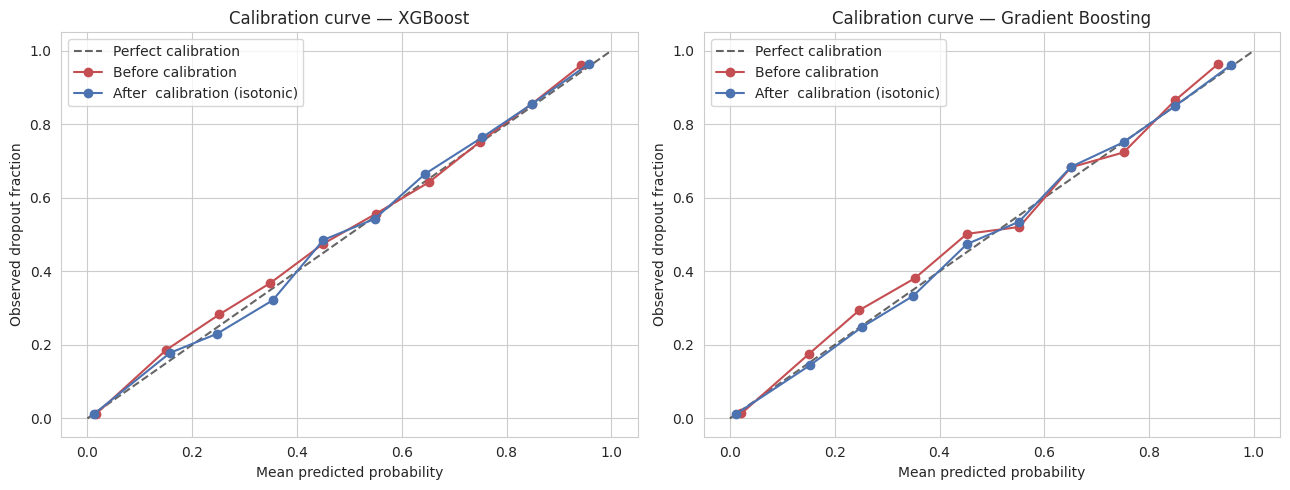

In [ ]:
# Calibration curves: before vs after
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (title, before_p, after_p) in zip(
    axes,
    [('XGBoost', xgb_probs, xgb_cal_probs),
     ('Gradient Boosting', gb_probs, gb_cal_probs)],
):
    ft, fp = calibration_curve(y_test, before_p, n_bins=10)
    ft2, fp2 = calibration_curve(y_test, after_p, n_bins=10)
    ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration', alpha=0.6)
    ax.plot(fp,  ft,  'o-', label='Before calibration', color='#C44E52')
    ax.plot(fp2, ft2, 'o-', label='After  calibration (isotonic)', color='#4C72B0')
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Observed dropout fraction')
    ax.set_title(f'Calibration curve — {title}')
    ax.legend()

plt.tight_layout(); plt.show()

## 13. Master comparison table — baseline vs default vs tuned vs calibrated

**Замечание научрука:** должно быть видно улучшение от шага к шагу.

In [ ]:
summary_rows = []
summary_rows.append(baseline_metrics)
for r in rows:
    if r['Model'] in ('Gradient Boosting', 'XGBoost'):
        r2 = r.copy(); r2['Model'] = r['Model'] + ' (default)'
        summary_rows.append(r2)
summary_rows.append(xgb_metrics)
summary_rows.append(gb_metrics)
summary_rows.append(xgb_cal_metrics)
summary_rows.append(gb_cal_metrics)

summary = pd.DataFrame(summary_rows)
if 'CV-F1 (5-fold)' in summary.columns:
    summary = summary.drop(columns=['CV-F1 (5-fold)'])
summary = summary[['Model', 'Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'Brier']]
summary.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Brier
0,Baseline (LogReg),0.8400,0.6900,0.8833,0.7748,0.9179,0.1188
1,Gradient Boosting (default),0.8642,0.7658,0.8129,0.7886,0.9362,0.0927
2,XGBoost (default),0.8595,0.7653,0.7917,0.7783,0.9377,0.0940
3,XGBoost (tuned),0.8664,0.7703,0.8139,0.7915,0.9418,0.0897
4,Gradient Boosting (tuned),0.8652,0.7669,0.8149,0.7902,0.9412,0.0897
5,XGBoost (calibrated),0.8659,0.7692,0.8139,0.7909,0.9423,0.0892
6,Gradient Boosting (calibrated),0.8653,0.7685,0.8124,0.7899,0.9406,0.0899


## 14. STEP 5 — Final model selection

Берём модель с лучшим балансом **F1 + ROC-AUC + Brier**.  
Обычно после Optuna + Calibration лучшим оказывается **XGBoost (calibrated)** или **Gradient Boosting (calibrated)** — зависит от прогона. Выбираем автоматически.

In [ ]:
# Score each candidate by composite: F1 + ROC-AUC - Brier
candidates = {
    'XGBoost (tuned)':            (xgb_best,         xgb_metrics),
    'Gradient Boosting (tuned)':  (gb_best,          gb_metrics),
    'XGBoost (calibrated)':       (xgb_calibrated,   xgb_cal_metrics),
    'Gradient Boosting (calibrated)': (gb_calibrated, gb_cal_metrics),
}
best_name, (best_model, best_metrics) = max(
    candidates.items(),
    key=lambda kv: kv[1][1]['F1'] + kv[1][1]['ROC-AUC'] - kv[1][1]['Brier']
)
print(f'>>> FINAL CHOSEN MODEL:  {best_name}')
print()
for k, v in best_metrics.items():
    print(f'  {k:10s} = {v:.4f}' if isinstance(v, float) else f'  {k:10s} = {v}')

>>> FINAL CHOSEN MODEL:  XGBoost (calibrated)

  Model      = XGBoost (calibrated)
  Accuracy   = 0.8659
  Precision  = 0.7692
  Recall     = 0.8139
  F1         = 0.7909
  ROC-AUC    = 0.9423
  Brier      = 0.0892


### 14.1 Confusion matrix + ROC curve for final model

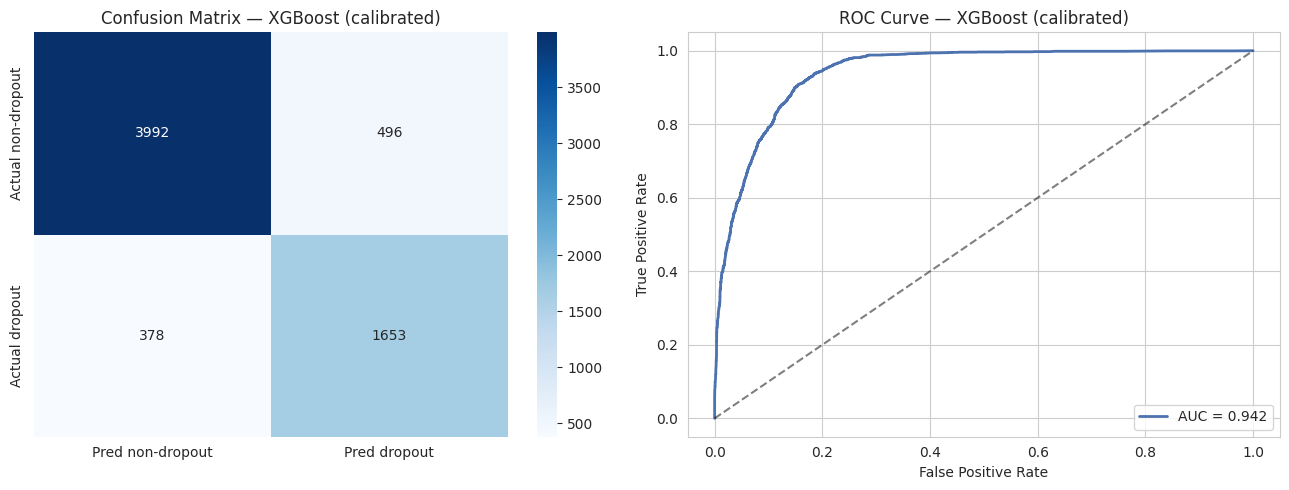


Classification report:
              precision    recall  f1-score   support

 non-dropout       0.91      0.89      0.90      4488
     dropout       0.77      0.81      0.79      2031

    accuracy                           0.87      6519
   macro avg       0.84      0.85      0.85      6519
weighted avg       0.87      0.87      0.87      6519



In [ ]:
final_probs = best_model.predict_proba(X_test_sc)[:, 1]
final_preds = (final_probs >= 0.5).astype(int)
cm = confusion_matrix(y_test, final_preds)

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred non-dropout', 'Pred dropout'],
            yticklabels=['Actual non-dropout', 'Actual dropout'], ax=ax[0])
ax[0].set_title(f'Confusion Matrix — {best_name}')

fpr, tpr, _ = roc_curve(y_test, final_probs)
ax[1].plot(fpr, tpr, label=f'AUC = {best_metrics["ROC-AUC"]:.3f}', color='#4C72B0', linewidth=2)
ax[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax[1].set_xlabel('False Positive Rate')
ax[1].set_ylabel('True Positive Rate')
ax[1].set_title(f'ROC Curve — {best_name}')
ax[1].legend(loc='lower right')

plt.tight_layout(); plt.show()

print('\nClassification report:')
print(classification_report(y_test, final_preds,
                            target_names=['non-dropout', 'dropout']))

## 15. STEP 6 — Explainability with SHAP

**Замечание научрука:** SHAP — ключ к защите. Нужно показать, **почему** модель так решила.  
Используем uncalibrated tuned XGBoost (TreeExplainer работает напрямую с tree-моделями, calibrated wrapper их прячет).

In [ ]:
# Use uncalibrated tuned XGBoost for SHAP (TreeExplainer needs raw tree model)
explainer = shap.TreeExplainer(xgb_best)

# Take a sample for speed (SHAP on 6k+ rows is slow)
sample_idx = np.random.RandomState(RANDOM_STATE).choice(
    len(X_test_sc), size=min(500, len(X_test_sc)), replace=False
)
X_test_sample = X_test_sc[sample_idx]
X_test_sample_orig = X_test_orig.iloc[sample_idx]

shap_values = explainer.shap_values(X_test_sample)
print(f'SHAP values computed for {len(X_test_sample)} samples')

SHAP values computed for 500 samples


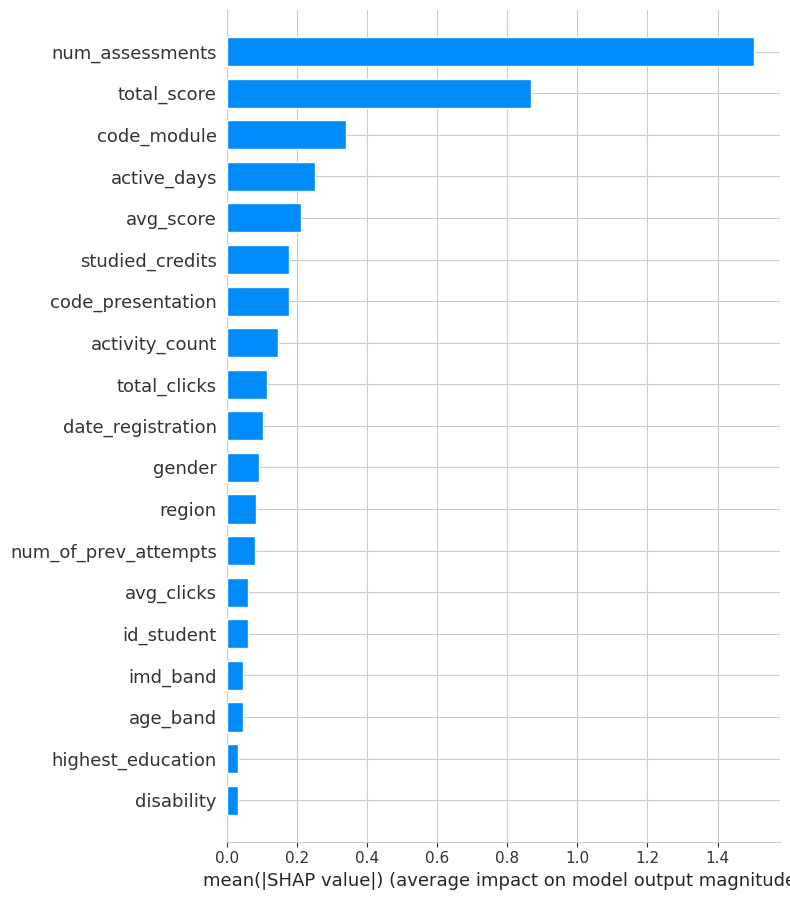

In [ ]:
# Summary plot — bar (global feature importance)
shap.summary_plot(shap_values, X_test_sample_orig,
                  feature_names=feature_names, plot_type='bar', show=True)

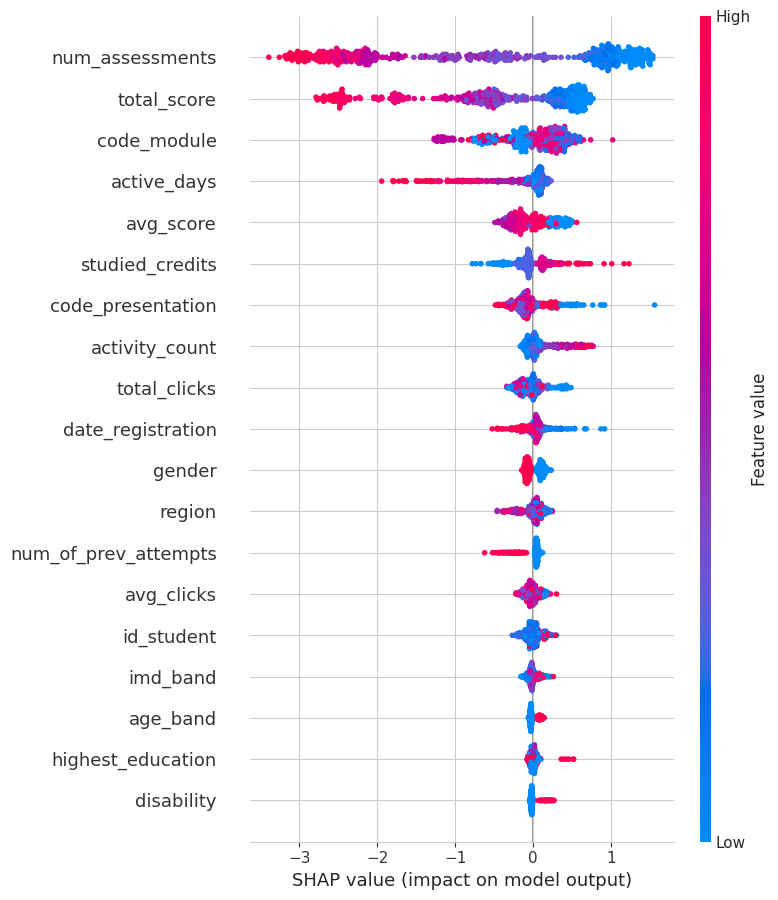

In [ ]:
# Summary plot — beeswarm (impact direction per feature)
shap.summary_plot(shap_values, X_test_sample_orig,
                  feature_names=feature_names, show=True)

High-risk student — predicted dropout prob = 1.000
Real label: 1


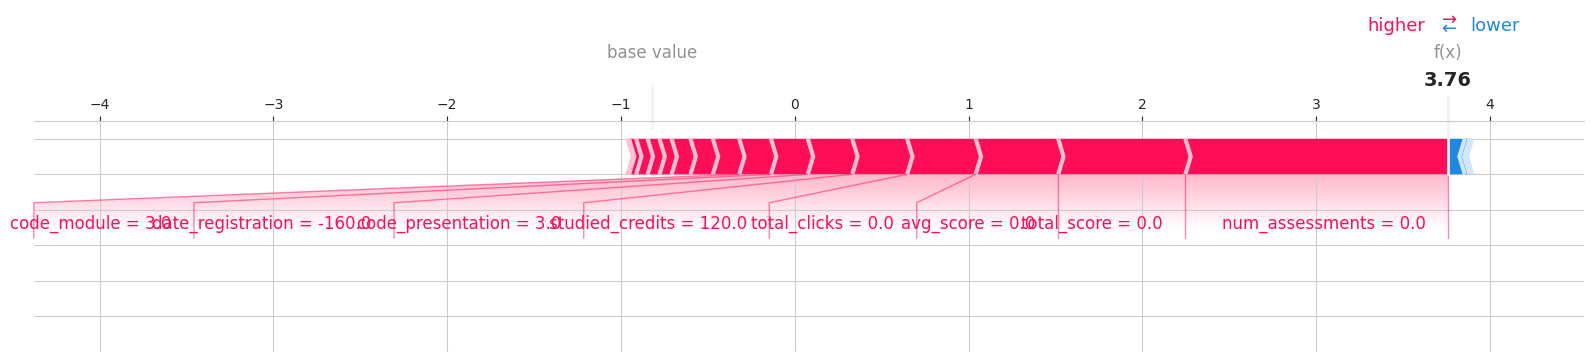

In [ ]:
# Force plot for a single high-risk student — “почему модель так решила”
high_risk_idx = np.argmax(final_probs[sample_idx])
print(f'High-risk student — predicted dropout prob = {final_probs[sample_idx][high_risk_idx]:.3f}')
print('Real label:', y_test.values[sample_idx][high_risk_idx])

shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values[high_risk_idx],
    X_test_sample_orig.iloc[high_risk_idx],
    matplotlib=True, show=True,
)

## 16. Sample predictions — high-risk vs low-risk students

Показываем, как система реально работает: вот студенты с высоким риском, вот с низким.

In [ ]:
demo = X_test_orig.copy()
demo['dropout_probability'] = final_probs
demo['predicted_dropout']   = final_preds
demo['actual']              = y_test.values

# Filter out empty / synthetic rows
demo = demo[(demo['total_clicks'] > 0) & (demo['avg_score'] > 0)]

high_risk = demo[demo['dropout_probability'] > 0.7].head(5)
low_risk  = demo[demo['dropout_probability'] < 0.2].head(5)
demo_display = pd.concat([high_risk, low_risk]).copy()
demo_display.insert(0, 'risk_group', ['HIGH']*len(high_risk) + ['LOW']*len(low_risk))

show_cols = ['risk_group', 'total_clicks', 'avg_clicks', 'activity_count',
             'avg_score', 'total_score', 'num_assessments',
             'dropout_probability', 'predicted_dropout', 'actual']
demo_display[show_cols].round(3)

,risk_group,total_clicks,avg_clicks,activity_count,avg_score,total_score,num_assessments,dropout_probability,predicted_dropout,actual
12061,HIGH,172.0,4.410,39.0,44.000,44.0,1.0,0.743,1,1
16762,HIGH,767.0,1.952,393.0,25.000,25.0,1.0,0.804,1,0
11096,HIGH,299.0,2.354,127.0,19.000,38.0,2.0,0.746,1,1
6738,HIGH,205.0,2.330,88.0,1.000,1.0,1.0,0.943,1,0
10620,HIGH,369.0,3.324,111.0,33.000,33.0,1.0,0.756,1,1
19947,LOW,1878.0,3.446,545.0,94.000,376.0,4.0,0.010,0,0
14427,LOW,1232.0,2.392,515.0,61.714,432.0,7.0,0.012,0,0
8193,LOW,462.0,3.609,128.0,68.600,343.0,5.0,0.036,0,0
7656,LOW,525.0,4.134,127.0,54.000,270.0,5.0,0.027,0,0
4221,LOW,342.0,2.359,145.0,96.091,1057.0,11.0,0.002,0,0


## 17. STEP 7 — Export final model + scaler

Это нужно для дашборда (отдельное приложение).

In [ ]:
joblib.dump(best_model,    'final_model.pkl')
joblib.dump(scaler,        'scaler.pkl')
joblib.dump(feature_names, 'feature_names.pkl')

import os
for f in ['final_model.pkl', 'scaler.pkl', 'feature_names.pkl']:
    print(f'✓ {f}  ({os.path.getsize(f)/1024:.1f} KB)')

print(f'\nExported model: {best_name}')
print(f'  F1      = {best_metrics["F1"]:.4f}')
print(f'  ROC-AUC = {best_metrics["ROC-AUC"]:.4f}')
print(f'  Brier   = {best_metrics["Brier"]:.4f}')

✓ final_model.pkl  (2426.3 KB)
✓ scaler.pkl  (1.5 KB)
✓ feature_names.pkl  (0.3 KB)

Exported model: XGBoost (calibrated)
  F1      = 0.7909
  ROC-AUC = 0.9423
  Brier   = 0.0892


## 18. Conclusion

Этот ноутбук реализует **полноценный ML pipeline + predictive system**:

| Шаг | Что сделано |
|-----|-------------|
| 1   | 7 raw OULAD таблиц → **1 агрегированный датасет** (~32k строк, 1 строка = студент × курс) |
| 2   | Stratified train/test split (80/20) с балансом классов в обеих частях |
| 3   | **5-fold cross-validation** (Stratified) на тренировочной части |
| 4   | **Baseline**: Logistic Regression — точка отсчёта |
| 5   | 6 моделей сравнены с baseline (RF, GB, XGB, SVM, KNN) |
| 6   | **Hyperparameter tuning (Optuna)** для XGBoost и Gradient Boosting |
| 7   | Расширенные метрики: **Accuracy, Precision, Recall, F1, ROC-AUC, Brier Score** |
| 8   | **Calibration** (`CalibratedClassifierCV`, isotonic) + calibration curves до/после |
| 9   | **SHAP explainability**: bar plot, beeswarm, force plot |
| 10  | Финальная модель выбрана автоматически по F1 + ROC-AUC − Brier |
| 11  | **Экспорт** модели + scaler + feature_names → `.pkl` для дашборда |

Дашборд (отдельное приложение) загружает `final_model.pkl` и `scaler.pkl` → даёт прогноз риска отчисления + объясняет SHAP-вкладами признаков.